# Phase 2 — Multi-Model Benchmarking
Trains and evaluates four models (Linear Regression, Random Forest, XGBoost, LSTM) across RMSE, MAE, and directional accuracy. Generates a comparison table and visualization saved to outputs/.

## Setup & Imports

In [9]:
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [10]:
import pickle

with open("../data/train_test_data.pkl", "rb") as f:
    data = pickle.load(f)

x_trained_scaled = data['x_trained_scaled']
x_test_scaled = data['x_test_scaled']
y_train = data['y_train']
y_test = data['y_test']
features = data['features']
y_scaler = MinMaxScaler()
print(f'Data loaded.')
print(f'X_train shape: {x_trained_scaled.shape}')
print(f'X_test shape: {x_test_scaled.shape}')

Data loaded.
X_train shape: (967, 9)
X_test shape: (242, 9)


## Model Evaluation Function

In [11]:
#let us create a model evaluation function w/ MAE and RMSE

def evaluate_model(name,y_true, y_pred):
    """
    Evalautes a regression model with metrics such as MAE, RMSE and directional accuracy
    Return a dict so it can be logged as a comparison table amongst different models
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    actual_direction = np.sign(np.diff(y_true))
    pred_direction = np.sign(np.diff(y_pred))
    dir_accuracy = np.mean(actual_direction == pred_direction) * 100

    print(f"\n{'='*40}")
    print(f"Model:                {name}")
    print(f"  RMSE:                 {rmse}")
    print(f"  MAE:                  {mae}")
    print(f"  Directional Accuracy: {dir_accuracy:.2f}%")
    print(f"\n{'='*40}")

    return{
        "model" : name,
        "rmse" : rmse,
        "mae": mae,
        "directional_accuracy": round(dir_accuracy,2)
    }

## XGBoost

In [12]:
xgb_model = XGBRegressor(
    n_estimators =1000,
    learning_rate =0.05,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree=0.8,
    random_state = 42
)
#let's fit the model
xgb_model.fit(
    x_trained_scaled, y_train,
    eval_set =[(x_test_scaled, y_test)],
    verbose = False
)
y_pred_xgb = xgb_model.predict(x_test_scaled)
result={}
result['XGBoost']= evaluate_model("XGBoost", y_test, y_pred_xgb)


Model:                XGBoost
  RMSE:                 11.012761699801299
  MAE:                  8.554282574614218
  Directional Accuracy: 67.22%



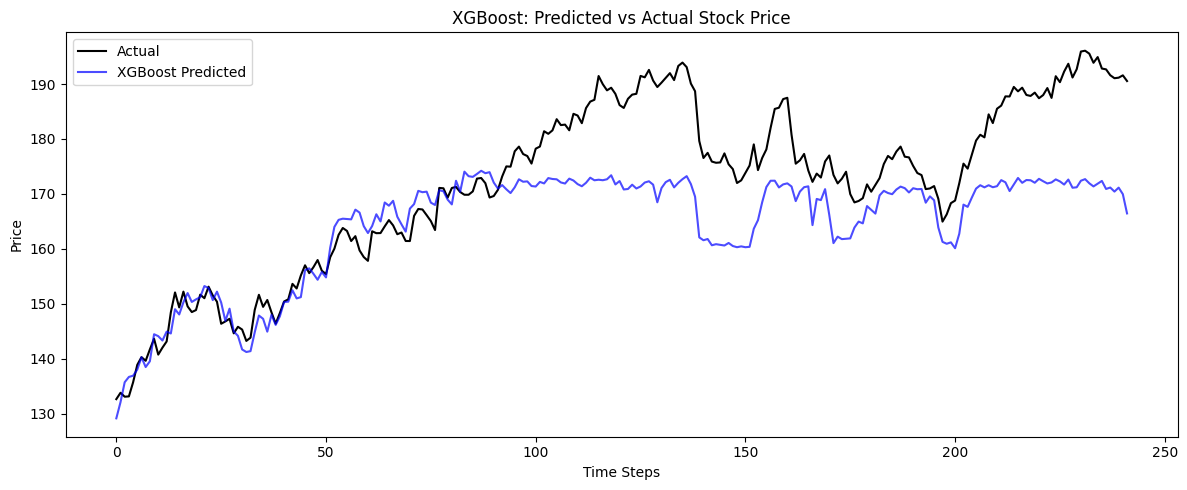

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(np.array(y_test).flatten(), label='Actual', color='black')
plt.plot(y_pred_xgb, label='XGBoost Predicted', color='blue', alpha=0.7)
plt.title('XGBoost: Predicted vs Actual Stock Price')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_trained_scaled, y_train)
y_pred_lr = lr_model.predict(x_test_scaled)
result['LinearRegression'] = evaluate_model("Linear Regression", y_test, y_pred_lr)


Model:                Linear Regression
  RMSE:                 2.0673765766595653
  MAE:                  1.578432590041512
  Directional Accuracy: 68.88%



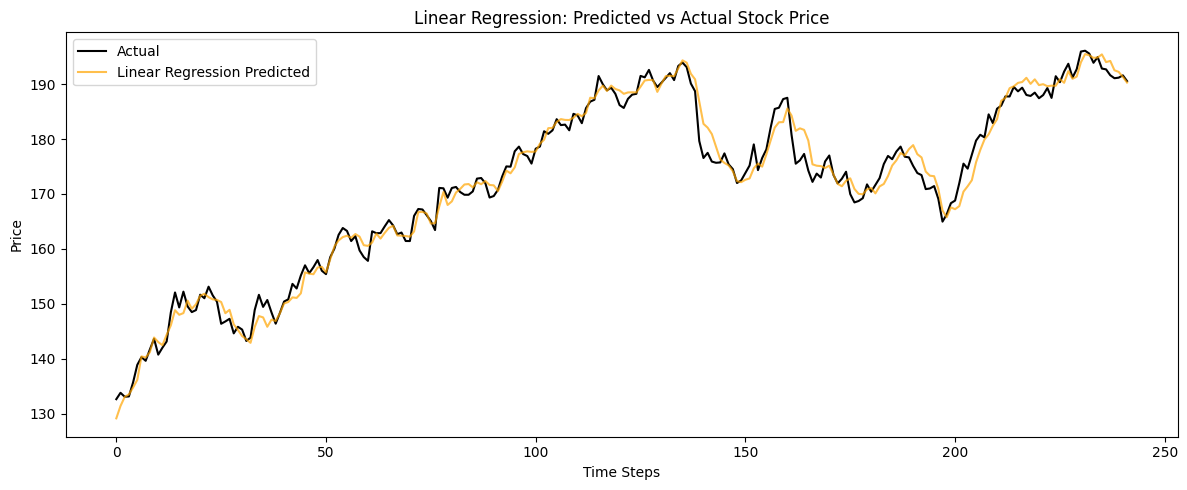

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(np.array(y_test).flatten(), label='Actual', color='black')
plt.plot(y_pred_lr, label='Linear Regression Predicted', color='orange', alpha=0.7)
plt.title('Linear Regression: Predicted vs Actual Stock Price')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators =100,
    max_depth = 6,
    max_features =0.8,
    random_state =42)

rf_model.fit(x_trained_scaled, y_train)
y_pred_rf = rf_model.predict(x_test_scaled)
result['RandomForest'] = evaluate_model('RandomForest', y_test, y_pred_rf)



Model:                RandomForest
  RMSE:                 10.599140553007398
  MAE:                  8.051550124063438
  Directional Accuracy: 63.90%



c:\Users\david\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


## LSTM — Sequence Preparation

In [17]:
#add another dim to the data. this will tell the model to look back a certain amount of days
def create_sequences(X,y, lookback=30):
    Xs , ys = [],[]
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback: i]) # this adds 30 days of features
        ys.append(y[i]) # the day of
    
    return np.array(Xs), np.array(ys)

In [18]:
x_seq, y_seq = create_sequences(x_trained_scaled, np.array(y_train), lookback= 30)
print(x_seq.shape)

(937, 30, 9)


In [19]:
y_seq_scaled = y_scaler.fit_transform(y_seq.reshape(-1,1)).flatten()
X_tensor = torch.FloatTensor(x_seq)
Y_tensor = torch.FloatTensor(y_seq_scaled).unsqueeze(1)

In [20]:
dataset = TensorDataset(X_tensor, Y_tensor)
loader =DataLoader(dataset, batch_size =32, shuffle =False)

## LSTM — Model Architecture & Training

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first= True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:,-1,:])
        return( self.fc(out))
    
model = LSTMModel(input_size= 9, hidden_size= 64, num_layers= 2)

In [22]:
#measures how wrong the model is and adam alg will adjust the weights
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [23]:
# let's train the model
epochs =50
for epoch in range(epochs):
    model.train()
    total_loss =0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch +1) %10 == 0:
        print(f'Epoch {epoch+1}/{epochs} Loss: {total_loss/len(loader):.4f}')

Epoch 10/50 Loss: 0.0078
Epoch 20/50 Loss: 0.0074
Epoch 30/50 Loss: 0.0058
Epoch 40/50 Loss: 0.0068
Epoch 50/50 Loss: 0.0034


In [24]:
x_test_seq, y_test_seq = create_sequences(np.array(x_test_scaled), np.array(y_test), lookback= 30)
y_test_seq_scaled = y_scaler.transform(y_test_seq.reshape(-1,1)).flatten()
x_test_tensor = torch.FloatTensor(x_test_seq)
model.eval()
with torch.no_grad():
    y_pred_scaled = model(x_test_tensor).numpy().flatten()
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_test_actual = y_scaler.inverse_transform(y_test_seq_scaled.reshape(-1,1)).flatten()
result['LSTM'] = evaluate_model('LSTM', y_test_actual, y_pred_lstm)


Model:                LSTM
  RMSE:                 7.2361234248947675
  MAE:                  5.971854299869171
  Directional Accuracy: 52.13%



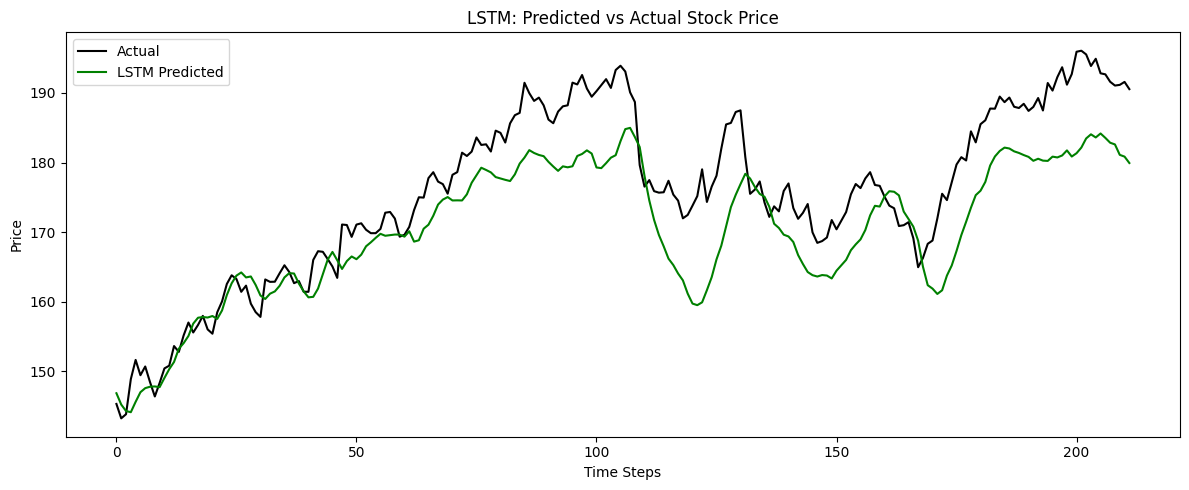

In [25]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label ='Actual', color ='black')
plt.plot(y_pred_lstm, label ='LSTM Predicted', color ='green')
plt.title('LSTM: Predicted vs Actual Stock Price')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## Model Comparison & Results

In [26]:
#let's store our results into a df table and prep the errors to be viewed as a graph
comparison_df = pd.DataFrame(result).T
comparison_df.index.name = "Model"
comparison_df = comparison_df.round(2)
comparison_df = comparison_df.sort_values('rmse',ascending= True)
print(comparison_df)

comparison_df.to_csv("../outputs/model_comparison.csv", index= True)
print(f'Comparison csv saved.')

                              model       rmse       mae directional_accuracy
Model                                                                        
LinearRegression  Linear Regression   2.067377  1.578433                68.88
LSTM                           LSTM   7.236123  5.971854                52.13
RandomForest           RandomForest  10.599141   8.05155                 63.9
XGBoost                     XGBoost  11.012762  8.554283                67.22
Comparison csv saved.


C:\Users\david\AppData\Local\Temp\ipykernel_36916\2226316142.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


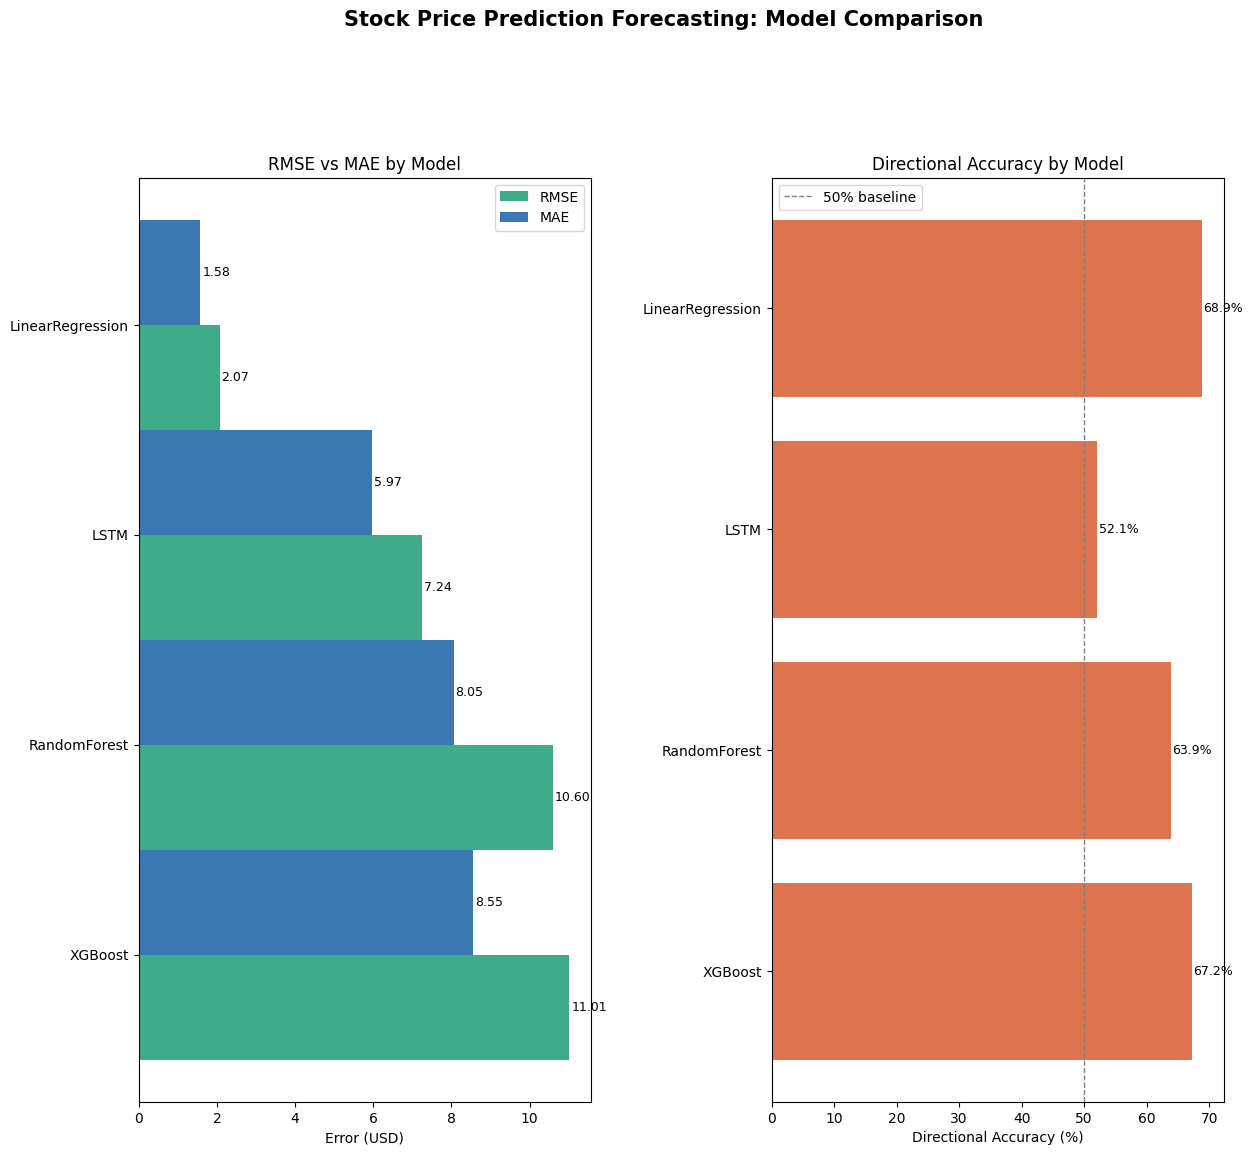

Chart saved.


In [27]:
colors =["#1D9E75", "#185FA5", "#D85A30", "#8B4FC4"]
fig =plt.figure(figsize=(14,12))
fig.suptitle('Stock Price Prediction Forecasting: Model Comparison',
             fontsize =15, fontweight = 'bold', y =1.02)

gs = gridspec.GridSpec(1,2, figure= fig, wspace =0.4)

models= comparison_df.index.tolist()

ax1 = fig.add_subplot(gs[0])
x = range(len(models))
width =0.5

bars1 =ax1.barh([i +width/2 for i in x],
                comparison_df['rmse'],
                height= width, label ='RMSE', color = colors[0],alpha =0.85)
bars2 = ax1.barh([ i - width/2 for i in x],
                 comparison_df['mae'],
                 height= width,label = 'MAE', color = colors[1], alpha =0.85)

ax1.set_yticks(list(x))
ax1.set_yticklabels(models)
ax1.set_xlabel('Error (USD)')
ax1.set_title('RMSE vs MAE by Model')
ax1.legend()
ax1.invert_yaxis()

for bar in bars1:
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}", va ="center", fontsize =9)
for bar in bars2:
    ax1.text(bar.get_width() +0.05, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.2f}", va ='center', fontsize =9)
    
ax2 =fig.add_subplot(gs[1])

bars3 = ax2.barh(models, comparison_df['directional_accuracy'],
                 color = colors[2], alpha =0.85)

ax2.axvline(x=50, color="gray", linestyle="--", linewidth=1, label="50% baseline")

ax2.set_xlabel("Directional Accuracy (%)")
ax2.set_title("Directional Accuracy by Model")
ax2.legend()
ax2.invert_yaxis()

for bar in bars3:
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Save Results

In [28]:
data['model_predictions'] ={
    'LinearRegression': y_pred_lr,
    'RandomForest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LSTM': y_pred_lstm
}

In [30]:
with open("../data/train_test_data.pkl", "wb") as f:
    pickle.dump(data,f)